---

## EDA — Sistema de Predicción Energética y Alerta Temprana en Barrios de Barcelona

> **Contexto:** Dataset con consumo eléctrico por código postal (bloques de 6h, 2019–2025), enriquecido con variables meteorológicas de estaciones Meteocat y temperatura superficial satelital (MODIS LST). El objetivo es **predecir el consumo eléctrico a nivel de barrio con horizonte 24–72h** y generar alertas tempranas de picos de demanda.

### Variables del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `cod_postal` | Categórica | Código postal de Barcelona (08001–08042) |
| `nombre_postal` | Categórica | Nombre del barrio asociado al código postal |
| `centroide_lon` | Numérica | Longitud del centroide del código postal |
| `centroide_lat` | Numérica | Latitud del centroide del código postal |
| `codi_estacio` | Categórica | Código de estación Meteocat asignada |
| `nombre_estacio` | Categórica | Nombre de la estación Meteocat asignada |
| `estacio_lon` | Numérica | Longitud de la estación Meteocat asignada |
| `estacio_lat` | Numérica | Latitud de la estación Meteocat asignada |
| `datetime` | Temporal | Inicio del bloque de 6 horas |
| `mwh_total` | Target | Consumo eléctrico total en MWh |
| `mwh_industria` | Numérica | Consumo sector industria |
| `mwh_residencial` | Numérica | Consumo sector residencial |
| `mwh_servicios` | Numérica | Consumo sector servicios |
| `mwh_no_especificado` | Numérica | Consumo no clasificado |
| `lst_celsius` | Numérica | Land Surface Temperature — MODIS (°C) |
| `temp_mean` | Numérica | Temperatura media Meteocat (°C) |
| `temp_max` | Numérica | Temperatura máxima Meteocat (°C) |
| `temp_min` | Numérica | Temperatura mínima Meteocat (°C) |
| `humedad_mean` | Numérica | Humedad relativa media (%) |
| `viento_mean` | Numérica | Velocidad media del viento (m/s) |
| `precipitacion_sum` | Numérica | Precipitación acumulada en el bloque (mm) |
| `irradiancia_mean` | Numérica | Irradiancia solar global media (W/m²) |
| `es_festivo` | Binaria | Es día festivo |
| `nombre_local` | Categórica | Nombre del festivo local |
| `hora` | Ordinal | Hora de inicio del bloque (0, 6, 12, 18) |
| `dia_semana` | Ordinal | Día de la semana (0=Lunes, 6=Domingo) |
| `mes` | Ordinal | Mes del año (1–12) |
| `anio` | Numérica | Año |
| `semana_anio` | Numérica | Semana del año (1–53) |
| `es_finde` | Binaria | Es fin de semana |

---
## <font color='#4E8F6E'>  **Librerías** </font>


In [306]:
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pymongo import MongoClient

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#D3D3D3'
plt.rcParams['grid.linewidth'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

verde   = '#4E8F6E'
naranj  = '#E07B5A'
amarill = '#D4B93A'
azul    = '#2B6CB0'

---
# <font color='#4E8F6E'>  **Carga y Exploración** </font>


In [ ]:
client = MongoClient('mongodb://mongo:27017/')
db     = client['tfm_energy']

docs = list(db['dataset_eda'].find({}, {'_id': 0}))
df   = pl.DataFrame(docs, infer_schema_length=None)


In [ ]:
df.head(6)

cod_postal,nombre_postal,centroide_lon,centroide_lat,codi_estacio,nombre_estacio,estacio_lon,estacio_lat,datetime,mwh_total,mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean,es_festivo,nombre_local,hora,dia_semana,mes,anio,semana_anio,es_finde
str,str,f64,f64,str,str,f64,f64,datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,i64,i64,i64,i64
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 00:00:00,70044,287,32270,37487,null,11.45,10.183333,10.9,9.4,77.833333,1.058333,0.0,-2.0,1,"""Año Nuevo""",0,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 06:00:00,84422,366,38319,45737,null,11.45,11.25,14.2,9.1,70.0,0.841667,0.0,176.083333,1,"""Año Nuevo""",6,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 12:00:00,106367,417,53880,52070,null,11.45,12.916667,13.5,11.9,70.083333,1.083333,0.0,94.916667,1,"""Año Nuevo""",12,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 18:00:00,103864,342,54490,49032,null,11.45,11.036364,11.5,10.6,74.818182,1.1,0.0,-3.0,1,"""Año Nuevo""",18,3,1,2025,1,0
"""08002""","""Barri Gòtic""",2.174238,41.382826,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 00:00:00,63203,788,20754,41661,null,11.44,10.183333,10.9,9.4,77.833333,1.058333,0.0,-2.0,1,"""Año Nuevo""",0,3,1,2025,1,0
"""08002""","""Barri Gòtic""",2.174238,41.382826,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 06:00:00,74533,1024,23581,49928,null,11.44,11.25,14.2,9.1,70.0,0.841667,0.0,176.083333,1,"""Año Nuevo""",6,3,1,2025,1,0


In [ ]:
df.tail(6)

cod_postal,nombre_postal,centroide_lon,centroide_lat,codi_estacio,nombre_estacio,estacio_lon,estacio_lat,datetime,mwh_total,mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean,es_festivo,nombre_local,hora,dia_semana,mes,anio,semana_anio,es_finde
str,str,f64,f64,str,str,f64,f64,datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,i64,i64,i64,i64
"""08041""","""Sant Andreu""",2.174434,41.418288,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 12:00:00,66201,1767,45480,18954,null,13.18,null,null,null,null,null,null,null,0,null,12,2,12,2019,1,0
"""08041""","""Sant Andreu""",2.174434,41.418288,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 18:00:00,61506,1394,46538,13574,null,13.18,null,null,null,null,null,null,null,0,null,18,2,12,2019,1,0
"""08042""","""Torre Baró / Nou Barris""",2.172027,41.444412,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 00:00:00,41996,759,22909,18328,null,12.21,null,null,null,null,null,null,null,0,null,0,2,12,2019,1,0
"""08042""","""Torre Baró / Nou Barris""",2.172027,41.444412,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 06:00:00,69314,1058,31561,36695,null,12.21,null,null,null,null,null,null,null,0,null,6,2,12,2019,1,0
"""08042""","""Torre Baró / Nou Barris""",2.172027,41.444412,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 12:00:00,84494,879,45909,37706,null,12.21,null,null,null,null,null,null,null,0,null,12,2,12,2019,1,0
"""08042""","""Torre Baró / Nou Barris""",2.172027,41.444412,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 18:00:00,82006,778,48307,32921,null,12.21,null,null,null,null,null,null,null,0,null,18,2,12,2019,1,0


In [ ]:
df.filter(pl.col("codi_estacio") == "X2").select(pl.col(["temp_mean", "temp_max", "temp_min", "humedad_mean", "viento_mean", "precipitacion_sum"])).head(6)

temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum
f64,f64,f64,f64,f64,f64
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null


In [ ]:
print(f"Shape: {df.shape}")
print(f"Desde: {df['datetime'].min()}")
print(f"Hasta: {df['datetime'].max()}")
print(f"Códigos postales únicos: {df['cod_postal'].n_unique()}")
print(f"Años cubiertos: {sorted(df['anio'].unique().to_list())}")


Shape: (424148, 30)
Desde: 2019-01-01 00:00:00
Hasta: 2025-11-30 18:00:00
Códigos postales únicos: 42
Años cubiertos: [2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [ ]:
# Tipos de datos
print("SCHEMA")
for col, dtype in zip(df.columns, df.dtypes):
    print(f"  {col:<30} {dtype}")


SCHEMA
  cod_postal                     String
  nombre_postal                  String
  centroide_lon                  Float64
  centroide_lat                  Float64
  codi_estacio                   String
  nombre_estacio                 String
  estacio_lon                    Float64
  estacio_lat                    Float64
  datetime                       Datetime(time_unit='us', time_zone=None)
  mwh_total                      Int64
  mwh_industria                  Int64
  mwh_residencial                Int64
  mwh_servicios                  Int64
  mwh_no_especificado            Int64
  lst_celsius                    Float64
  temp_mean                      Float64
  temp_max                       Float64
  temp_min                       Float64
  humedad_mean                   Float64
  viento_mean                    Float64
  precipitacion_sum              Float64
  irradiancia_mean               Float64
  es_festivo                     Int64
  nombre_local                   

In [ ]:
pl.Config.set_tbl_rows(50)

nulls = (
    pl.DataFrame({
        'columna': df.columns,
        'nulos':   [df[c].null_count() for c in df.columns]
    })
    .with_columns((pl.col('nulos') / len(df) * 100).round(2).alias('pct_nulos'))
    .sort('nulos', descending=True)
    .filter(pl.col('nulos') > 0)
)

print(nulls)

shape: (12, 3)
┌─────────────────────┬────────┬───────────┐
│ columna             ┆ nulos  ┆ pct_nulos │
│ ---                 ┆ ---    ┆ ---       │
│ str                 ┆ i64    ┆ f64       │
╞═════════════════════╪════════╪═══════════╡
│ nombre_local        ┆ 407184 ┆ 96.0      │
│ mwh_no_especificado ┆ 362004 ┆ 85.35     │
│ lst_celsius         ┆ 168824 ┆ 39.8      │
│ viento_mean         ┆ 153201 ┆ 36.12     │
│ irradiancia_mean    ┆ 153196 ┆ 36.12     │
│ temp_mean           ┆ 136527 ┆ 32.19     │
│ temp_max            ┆ 136527 ┆ 32.19     │
│ temp_min            ┆ 136527 ┆ 32.19     │
│ humedad_mean        ┆ 136516 ┆ 32.19     │
│ precipitacion_sum   ┆ 136428 ┆ 32.17     │
│ mwh_industria       ┆ 2444   ┆ 0.58      │
│ mwh_residencial     ┆ 40     ┆ 0.01      │
└─────────────────────┴────────┴───────────┘


# Distribución por código postal

In [ ]:
codpos_null = (# Nulos de variables meteo por año — así ves cuándo se rompe la estación
df.group_by('anio').agg([
    pl.col('irradiancia_mean').is_null().sum().alias('nulos_irradiancia'),
    pl.col('viento_mean').is_null().sum().alias('nulos_viento'),
    pl.col('temp_mean').is_null().sum().alias('nulos_temp'),
    pl.col('humedad_mean').is_null().sum().alias('nulos_humedad'),
    pl.len().alias('total_registros')
]).sort('anio'))

print(codpos_null)

shape: (7, 6)
┌──────┬───────────────────┬──────────────┬────────────┬───────────────┬─────────────────┐
│ anio ┆ nulos_irradiancia ┆ nulos_viento ┆ nulos_temp ┆ nulos_humedad ┆ total_registros │
│ ---  ┆ ---               ┆ ---          ┆ ---        ┆ ---           ┆ ---             │
│ i64  ┆ u32               ┆ u32          ┆ u32        ┆ u32           ┆ u32             │
╞══════╪═══════════════════╪══════════════╪════════════╪═══════════════╪═════════════════╡
│ 2019 ┆ 21900             ┆ 21900        ┆ 18980      ┆ 18980         ┆ 61320           │
│ 2020 ┆ 22504             ┆ 22504        ┆ 19616      ┆ 19616         ┆ 61488           │
│ 2021 ┆ 22440             ┆ 22440        ┆ 19560      ┆ 19560         ┆ 61320           │
│ 2022 ┆ 22116             ┆ 22123        ┆ 19219      ┆ 19219         ┆ 61320           │
│ 2023 ┆ 21900             ┆ 21900        ┆ 18980      ┆ 18980         ┆ 61320           │
│ 2024 ┆ 22094             ┆ 22078        ┆ 19923      ┆ 19919         ┆ 614

> Los nulls de viento e irradiancia son constantes por todos los años, puede ser que sean dias específicos del años o simepleemente que solo algunas estacionas puedan lograr tomar estas medidas. aproximadamente 17,500 nullos al año

> En cambio partes de 2024 y 2025 son valores un poco diferentes, que curiosamente se acercan a las constantes de nulos de irradiancia y viento

Nulls viento

In [ ]:
codpos_null = (df.filter(pl.col('viento_mean').is_null())
    .group_by(['cod_postal','nombre_postal','codi_estacio'])
    .agg(pl.len().alias('nulos_viento'))
    .sort('nulos_viento', descending=True)
    .select(['cod_postal','nombre_postal', 'nulos_viento','codi_estacio']))

print(codpos_null)

shape: (42, 4)
┌────────────┬─────────────────────────────────┬──────────────┬──────────────┐
│ cod_postal ┆ nombre_postal                   ┆ nulos_viento ┆ codi_estacio │
│ ---        ┆ ---                             ┆ ---          ┆ ---          │
│ str        ┆ str                             ┆ u32          ┆ str          │
╞════════════╪═════════════════════════════════╪══════════════╪══════════════╡
│ 08026      ┆ El Clot / Camp de l'Arpa        ┆ 10100        ┆ AN           │
│ 08010      ┆ Pl. Catalunya / Gran Via        ┆ 10100        ┆ AN           │
│ 08030      ┆ El Bon Pastor / Sant Andreu     ┆ 10100        ┆ AN           │
│ 08005      ┆ El Poblenou                     ┆ 10100        ┆ X2           │
│ 08018      ┆ Fort Pienc                      ┆ 10100        ┆ AN           │
│ 08027      ┆ La Sagrera                      ┆ 10100        ┆ AN           │
│ 08009      ┆ Dreta de l'Eixample             ┆ 10100        ┆ AN           │
│ 08025      ┆ El Guinardó           

> Los nulos de irradiancia y viento son estructurales desde 2019: la estación X2
> de Meteocat no dispone de estos sensores para la mayoría de códigos postales.
> No es un fallo temporal sino una limitación permanente de cobertura.

> La excepción es el código postal 08038, que tiene asignada otra estación
> con cobertura completa de variables, confirmando que el problema es de
> estación y no de los días o periodos de medición.

> En 2024 y 2025 los nulos de temperatura y humedad escalan bruscamente hasta
> igualarse con los de irradiancia y viento. Esto confirma la degradación
> progresiva y posterior inactividad de la estación X2, que en 2025 deja de
> reportar prácticamente todas las variables.

> Estrategia de imputación pendiente para feature engineering: reasignar X2
> a X4 o aplicar un factor de corrección histórico. MODIS actuará como
> fallback espacial para LST en periodos sin cobertura de estación.

In [ ]:
df.group_by(["codi_estacio", "anio"]).agg([
    pl.len().alias("total_registros"),
    pl.col("temp_mean").is_null().sum().alias("nulos_temp"),
    pl.col("viento_mean").is_null().sum().alias("nulos_viento"),
    pl.col("irradiancia_mean").is_null().sum().alias("nulos_irradiancia"),
]).sort(["codi_estacio", "anio"])

codi_estacio,anio,total_registros,nulos_temp,nulos_viento,nulos_irradiancia
str,i64,u32,u32,u32,u32
"""AN""",2019,18980,18980,18980,18980
"""AN""",2020,19032,19032,19032,19032
"""AN""",2021,18980,18980,18980,18980
"""AN""",2022,18980,18980,18980,18980
"""AN""",2023,18980,18980,18980,18980
"""AN""",2024,19032,19032,19032,19032
"""AN""",2025,17316,17316,17316,17316
"""D5""",2019,10220,0,0,0
"""D5""",2020,10248,140,140,140


In [ ]:
# Ver qué estaciones tienen mejor cobertura de temperatura
df.group_by("codi_estacio").agg([
    pl.len().alias("total"),
    pl.col("temp_mean").is_null().sum().alias("nulos_temp"),
    (pl.col("temp_mean").is_null().sum() / pl.len() * 100).round(2).alias("pct_nulos_temp")
]).sort("pct_nulos_temp")

codi_estacio,total,nulos_temp,pct_nulos_temp
str,u32,u32,f64
"""X4""",161548,928,0.57
"""X8""",40400,252,0.62
"""D5""",70700,567,0.8
"""X2""",20200,3480,17.23
"""AN""",131300,131300,100.0


- X4 : 0.57% nulos 
- X8 : 0.62% nulos 
- D5 : 0.80% nulos  
- X2 : 17.23% nulos 
- AN : 100% nulos

> **Estación AN — Parc de la Ciutadella:** Al cruzar el mapeo geográfico con los datos reales de MongoDB, se descubrió que AN y X2 (Zoo de Barcelona) se solapan físicamente, a menos de 200 metros dentro del mismo parque. Más importante aún, AN tiene el 100% de nulos en todas sus variables meteorológicas en todos los años (2019–2025), lo que confirma que AN existe como punto de referencia geográfico en Meteocat pero no dispone de sensores activos. Por esta razón, tomo la decisión de reasignar todos los registros originalmente asignados a AN hacia X2, que sí tiene datos de temperatura.

> **Estación X2 — Zoo de Barcelona:** X2 presenta dos limitaciones estructurales. Primero, nunca ha tenido sensores de viento ni irradiancia ya que ambas variables tienen el 100% de nulos en todos los años, lo cual no es un fallo sino una característica de la estación. Segundo, a partir de 2024 comienza a degradarse y en 2025 deja de funcionar completamente, con 2.664 nulos de temperatura sobre 2.664 registros totales. Para los CPs asignados a X2, las variables de viento e irradiancia deberán ser imputadas en la fase de feature engineering, ya sea mediante la estación más cercana con cobertura completa o mediante un factor de corrección basado en la diferencia de temperatura superficial con MODIS.

---
# <font color='#4E8F6E'>  **Limpieza inicial** </font>


> A partir de los hallazgos anteriores comenzaré con una limpieza inicial

### <font color='#D4B93A'><b>Datos Faltantes</b></font>

In [ ]:
mwh_problematicos = df.filter(pl.col('mwh_total') <= 0)
print(f"Registros con mwh_total <= 0: {len(mwh_problematicos):,}")

n_dupes = len(df) - df.unique(subset=['datetime', 'cod_postal']).shape[0]
print(f"Duplicados (datetime + cod_postal): {n_dupes:,}")


Registros con mwh_total <= 0: 378


Duplicados (datetime + cod_postal): 0


> Existen 378 filas donde no existen valores iguales o menores a 0 en el mwh_total lo cual se puede tratar de un problema de recolección de datos

In [ ]:
print(mwh_problematicos.select([
    "cod_postal", "nombre_postal", "datetime",
    "mwh_total", "mwh_industria", "mwh_residencial",
    "mwh_servicios", "mwh_no_especificado"
]))

shape: (378, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ cod_postal ┆ nombre_pos ┆ datetime   ┆ mwh_total ┆ mwh_indus ┆ mwh_resid ┆ mwh_servi ┆ mwh_no_es │
│ ---        ┆ tal        ┆ ---        ┆ ---       ┆ tria      ┆ encial    ┆ cios      ┆ pecificad │
│ str        ┆ ---        ┆ datetime[μ ┆ i64       ┆ ---       ┆ ---       ┆ ---       ┆ o         │
│            ┆ str        ┆ s]         ┆           ┆ i64       ┆ i64       ┆ i64       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆           ┆           ┆ i64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 08001      ┆ Las        ┆ 2025-06-26 ┆ 0         ┆ 0         ┆ 0         ┆ 0         ┆ null      │
│            ┆ Ramblas /  ┆ 00:00:00   ┆           ┆           ┆           ┆           ┆           │
│            ┆ El Raval   ┆            ┆           ┆           ┆           

In [ ]:
print(mwh_problematicos.select("datetime").unique().sort("datetime"))

shape: (9, 1)
┌─────────────────────┐
│ datetime            │
│ ---                 │
│ datetime[μs]        │
╞═════════════════════╡
│ 2025-06-26 00:00:00 │
│ 2025-06-26 06:00:00 │
│ 2025-06-26 12:00:00 │
│ 2025-08-30 00:00:00 │
│ 2025-08-30 06:00:00 │
│ 2025-08-30 12:00:00 │
│ 2025-09-07 00:00:00 │
│ 2025-09-07 06:00:00 │
│ 2025-09-07 12:00:00 │
└─────────────────────┘


In [ ]:
fechas_problema = ["2025-06-26", "2025-08-30", "2025-09-07"]

df.filter(
    (pl.col("datetime").dt.date().cast(pl.Utf8).is_in(fechas_problema)) &
    (pl.col("datetime").dt.hour() == 18)
).select(["cod_postal", "datetime", "mwh_total"]).head(10)

cod_postal,datetime,mwh_total
str,datetime[μs],i64
"""08001""",2025-06-26 18:00:00,9128
"""08002""",2025-06-26 18:00:00,5176
"""08003""",2025-06-26 18:00:00,9266
"""08004""",2025-06-26 18:00:00,8587
"""08005""",2025-06-26 18:00:00,8008
"""08006""",2025-06-26 18:00:00,12091
"""08007""",2025-06-26 18:00:00,2200
"""08008""",2025-06-26 18:00:00,1660
"""08009""",2025-06-26 18:00:00,1892


In [ ]:
mwh_problematicos.group_by("datetime") \
    .agg(pl.n_unique("cod_postal").alias("n_codigos")) \
    .sort("datetime")

datetime,n_codigos
datetime[μs],u32
2025-06-26 00:00:00,42
2025-06-26 06:00:00,42
2025-06-26 12:00:00,42
2025-08-30 00:00:00,42
2025-08-30 06:00:00,42
2025-08-30 12:00:00,42
2025-09-07 00:00:00,42
2025-09-07 06:00:00,42
2025-09-07 12:00:00,42


> Este error en lso datos existe durante todos lo días para los 42 códigos postales

### <font color='#D4B93A'><b>Verificar continuidad temporal</b></font>

In [ ]:
# Generar la grilla completa esperada
fechas_completas = pl.datetime_range(  # ← datetime_range, no date_range
    start=df['datetime'].min(),
    end=df['datetime'].max(),
    interval='6h',
    eager=True
).alias('datetime')

codigos_postales = df.select('cod_postal').unique()

grilla_esperada = codigos_postales.join(
    fechas_completas.to_frame(), how='cross'
)

print(f"Registros esperados: {len(grilla_esperada):,}")
print(f"Registros reales:    {len(df):,}")
print(f"Registros faltantes: {len(grilla_esperada) - len(df):,}")

faltantes = grilla_esperada.join(
    df.select(['cod_postal', 'datetime']),
    on=['cod_postal', 'datetime'],
    how='anti'
)

print("\nFechas con mayor número de CP faltantes:")
print(
    faltantes
    .group_by(pl.col('datetime').dt.date().alias('fecha'))
    .agg(pl.len().alias('cp_faltantes'))
    .sort('cp_faltantes', descending=True)
    .head(20)
)

Registros esperados: 424,368
Registros reales:    424,148
Registros faltantes: 220

Fechas con mayor número de CP faltantes:
shape: (14, 2)
┌────────────┬──────────────┐
│ fecha      ┆ cp_faltantes │
│ ---        ┆ ---          │
│ date       ┆ u32          │
╞════════════╪══════════════╡
│ 2025-08-19 ┆ 168          │
│ 2025-08-09 ┆ 4            │
│ 2025-08-12 ┆ 4            │
│ 2025-08-17 ┆ 4            │
│ 2025-08-18 ┆ 4            │
│ 2025-08-13 ┆ 4            │
│ 2025-08-08 ┆ 4            │
│ 2025-08-15 ┆ 4            │
│ 2025-08-20 ┆ 4            │
│ 2025-08-14 ┆ 4            │
│ 2025-08-11 ┆ 4            │
│ 2025-08-07 ┆ 4            │
│ 2025-08-10 ┆ 4            │
│ 2025-08-16 ┆ 4            │
└────────────┴──────────────┘


In [ ]:
faltantes_por_dia = faltantes.with_columns(
    pl.col("datetime").dt.date().alias("fecha")
).group_by(["cod_postal", "fecha"]).count()

faltantes_por_dia.filter(
    pl.col("count") != 4  # 4 registros por día (cada 6h)
)

/tmp/ipykernel_1710/2924495419.py:3: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  ).group_by(["cod_postal", "fecha"]).count()


cod_postal,fecha,count
str,date,u32


A todos estos días les faltan 4 los 4 horarios

### <font color='#D4B93A'><b>Conversión de tipo de datos</b></font>

In [ ]:
df = df.with_columns([
    pl.col('datetime').cast(pl.Datetime),
    pl.col('cod_postal').cast(pl.Utf8),
    pl.col('es_festivo').cast(pl.Int8),
    pl.col('es_finde').cast(pl.Int8),
    pl.col('hora').cast(pl.Int8),
    pl.col('dia_semana').cast(pl.Int8),
    pl.col('mes').cast(pl.Int8),
    pl.col('anio').cast(pl.Int16),
])
df.head(3)


cod_postal,nombre_postal,centroide_lon,centroide_lat,codi_estacio,nombre_estacio,estacio_lon,estacio_lat,datetime,mwh_total,mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean,es_festivo,nombre_local,hora,dia_semana,mes,anio,semana_anio,es_finde
str,str,f64,f64,str,str,f64,f64,datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i8,str,i8,i8,i8,i16,i64,i8
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 00:00:00,70044,287,32270,37487,null,11.45,10.183333,10.9,9.4,77.833333,1.058333,0.0,-2.0,1,"""Año Nuevo""",0,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 06:00:00,84422,366,38319,45737,null,11.45,11.25,14.2,9.1,70.0,0.841667,0.0,176.083333,1,"""Año Nuevo""",6,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 12:00:00,106367,417,53880,52070,null,11.45,12.916667,13.5,11.9,70.083333,1.083333,0.0,94.916667,1,"""Año Nuevo""",12,3,1,2025,1,0


> Se identificaron 378 registros con mwh_total = 0, correspondientes a los bloques de 00:00, 06:00 y 12:00 de tres fechas puntuales en 2025, estos son: 26 de junio, 30 de agosto y 7 de septiembre. 

> En los tres casos el patrón es idéntico: afectan a los 42 códigos postales simultáneamente y el bloque de 18:00 del mismo día reporta valores normales (por ejemplo, 08001 registró 9.128 MWh a las 18:00 del 26 de junio). 

> Esto descarta un apagón real y confirma un fallo parcial de reporte en la fuente Open Data BCN, limitado a los primeros tres bloques del día. Estos registros serán tratados como nulos en la fase de feature engineering.

### <font color='#D4B93A'><b>Trato de Nulls</b></font>


A partir de la exploración inicial y la e
1. Reasignación AN → X2
    - Temperaturas, humedad
    - irradiación, precipitacion y viento
2. Imputación de los 3 días con ceros con valores de dia anterior y posterior (media)
3. Relleno de datos que evitan continuidad
4. Revisión del resto de nulos

1. Reasignación AN → X2
    - Temperaturas, humedad, precipitacion

In [ ]:
df = df.with_columns(
    pl.when(pl.col("codi_estacio") == "AN")
      .then(pl.lit(1))
      .otherwise(pl.lit(0))
      .cast(pl.Int8)
      .alias("_era_AN")
)

In [ ]:
df = df.with_columns(
    pl.when(pl.col("codi_estacio") == "AN")
      .then(pl.lit("X2"))
      .otherwise(pl.col("codi_estacio"))
      .alias("codi_estacio"),

    pl.when(pl.col("codi_estacio") == "AN")
      .then(pl.lit("Barcelona - Zoo"))
      .otherwise(pl.col("nombre_estacio"))
      .alias("nombre_estacio"),

    pl.when(pl.col("codi_estacio") == "AN")
      .then(pl.lit(2.1898))
      .otherwise(pl.col("estacio_lon"))
      .alias("estacio_lon"),

    pl.when(pl.col("codi_estacio") == "AN")
      .then(pl.lit(41.3842))
      .otherwise(pl.col("estacio_lat"))
      .alias("estacio_lat"),
)

print(df.group_by("codi_estacio").agg(pl.len().alias("n")).sort("codi_estacio"))

shape: (4, 2)
┌──────────────┬────────┐
│ codi_estacio ┆ n      │
│ ---          ┆ ---    │
│ str          ┆ u32    │
╞══════════════╪════════╡
│ D5           ┆ 70700  │
│ X2           ┆ 151500 │
│ X4           ┆ 161548 │
│ X8           ┆ 40400  │
└──────────────┴────────┘


In [ ]:
docs_meteocat = list(db["clean_meteocat"].find({"codi_estacio": "X2"}, {"_id": 0}))
meteocat_x2 = (
    pl.DataFrame(docs_meteocat)
    .rename({
        "data_lectura": "datetime",
        "temp":         "temp_mean",
        "humedad":      "humedad_mean",
        "viento":       "viento_mean",
        "precipitacion":"precipitacion_sum",
        "irradiancia":  "irradiancia_mean",
    })
    .select(["datetime", "temp_mean", "humedad_mean", "viento_mean",
             "precipitacion_sum", "irradiancia_mean"])
)

df = df.join(meteocat_x2, on="datetime", how="left", suffix="_x2")

cols_meteo = ["temp_mean", "humedad_mean", "viento_mean",
              "precipitacion_sum", "irradiancia_mean"]

df = df.with_columns([
    pl.when(pl.col("_era_AN") == 1)
      .then(pl.col(f"{c}_x2"))
      .otherwise(pl.col(c))
      .alias(c)
    for c in cols_meteo
])

df = df.drop([f"{c}_x2" for c in cols_meteo] + ["_era_AN"])
print(df.shape)

(424148, 30)


In [ ]:
# ¿El join respetó la estación o mezcló datos?
print(
    df.group_by("codi_estacio")
    .agg(
        pl.col("temp_mean").null_count().alias("nulos_temp"),
        pl.len().alias("total")
    )
    .sort("codi_estacio")
)

shape: (4, 3)
┌──────────────┬────────────┬────────┐
│ codi_estacio ┆ nulos_temp ┆ total  │
│ ---          ┆ ---        ┆ ---    │
│ str          ┆ u32        ┆ u32    │
╞══════════════╪════════════╪════════╡
│ D5           ┆ 567        ┆ 70700  │
│ X2           ┆ 26165      ┆ 151500 │
│ X4           ┆ 928        ┆ 161548 │
│ X8           ┆ 252        ┆ 40400  │
└──────────────┴────────────┴────────┘


### Estrategia de nulos meteorológicos — decisión EDA

**Variables: viento_mean, irradiancia_mean, precipitacion_sum**
X2 no mide estas variables en ningún período.
→ Mantener nulos. Si el EDA muestra diferencias significativas entre barrios,
  explorar fuentes alternativas (otras estaciones, ERA5).

**Variables: temp_mean, humedad_mean — período 2024 parcial y 2025**
X2 inactiva. Datos reales disponibles para 2019–2023.
→ Mantener nulos por ahora. Si el EDA confirma diferencias de comportamiento
  entre barrios (consumo vs temperatura), aplicar factor de corrección
  basado en la relación histórica X2/X4 de años anteriores.

**Criterio de decisión (post-EDA):**
- Si variación entre barrios es baja → nulos sin imputar, el modelo los gestiona
- Si variación entre barrios es alta → factor de corrección histórico X2/X4

2. Imputación de los 3 días con ceros. mismo bloque horario, misma semana del año, años anteriores.

Imputación pr media de día anterior y posterior

In [ ]:
df = df.sort(["cod_postal", "hora", "datetime"])

# Imputar: promedio del valor anterior y siguiente por CP+hora
df = df.with_columns(
    pl.when(pl.col("mwh_total") == 0)
      .then(
          (pl.col("mwh_total").shift(1).over(["cod_postal", "hora"]) +
           pl.col("mwh_total").shift(-1).over(["cod_postal", "hora"])) / 2
      )
      .otherwise(pl.col("mwh_total"))
      .alias("mwh_total")
)

print(f"Ceros restantes: {df.filter(pl.col('mwh_total') == 0).shape[0]}")
df_buenos = df.filter(pl.col("mwh_total") > 0)
df_ceros = df.filter(pl.col("mwh_total") <= 0)



Ceros restantes: 0


3. Relleno de datos que evitan continuidad

In [ ]:
print(f"Registros esperados: {len(grilla_esperada):,}")
print(f"Registros reales:    {len(df):,}")
print(f"Registros faltantes: {len(grilla_esperada) - len(df):,}")

print("\nFechas con mayor número de CP faltantes:")
print(
    faltantes
    .group_by(pl.col('datetime').dt.date().alias('fecha'))
    .agg(pl.len().alias('cp_faltantes'))
    .sort('cp_faltantes', descending=True)
    .head(20)
)

Registros esperados: 424,368
Registros reales:    424,148
Registros faltantes: 220

Fechas con mayor número de CP faltantes:
shape: (14, 2)
┌────────────┬──────────────┐
│ fecha      ┆ cp_faltantes │
│ ---        ┆ ---          │
│ date       ┆ u32          │
╞════════════╪══════════════╡
│ 2025-08-19 ┆ 168          │
│ 2025-08-08 ┆ 4            │
│ 2025-08-20 ┆ 4            │
│ 2025-08-10 ┆ 4            │
│ 2025-08-17 ┆ 4            │
│ 2025-08-12 ┆ 4            │
│ 2025-08-18 ┆ 4            │
│ 2025-08-16 ┆ 4            │
│ 2025-08-13 ┆ 4            │
│ 2025-08-15 ┆ 4            │
│ 2025-08-14 ┆ 4            │
│ 2025-08-11 ┆ 4            │
│ 2025-08-07 ┆ 4            │
│ 2025-08-09 ┆ 4            │
└────────────┴──────────────┘


In [ ]:
from datetime import date

print(
    faltantes
    .filter(pl.col('datetime').dt.date() != date(2025, 8, 19))
    .group_by('cod_postal')
    .agg(pl.len().alias('n'))
    .sort('n', descending=True)
)

shape: (1, 2)
┌────────────┬─────┐
│ cod_postal ┆ n   │
│ ---        ┆ --- │
│ str        ┆ u32 │
╞════════════╪═════╡
│ 08011      ┆ 52  │
└────────────┴─────┘


- 08011 → le faltan 52 bloques durante agosto (13 días × 4 bloques). Problema de reporte específico de ese CP.
- 2025-08-19 → día completo sin datos para 42 CPs (168 bloques). Mismo patrón que los 3 días con ceros, fallo de reporte en la fuente.

In [ ]:
print(
    df.filter(
        (pl.col('cod_postal') == '08011') &
        (pl.col('mes') == 8)
    )
    .group_by('anio')
    .agg(
        pl.col('mwh_total').count().alias('registros'),
        pl.col('mwh_total').null_count().alias('nulls')
    )
    .sort('anio')
)

shape: (7, 3)
┌──────┬───────────┬───────┐
│ anio ┆ registros ┆ nulls │
│ ---  ┆ ---       ┆ ---   │
│ i16  ┆ u32       ┆ u32   │
╞══════╪═══════════╪═══════╡
│ 2019 ┆ 124       ┆ 0     │
│ 2020 ┆ 124       ┆ 0     │
│ 2021 ┆ 124       ┆ 0     │
│ 2022 ┆ 124       ┆ 0     │
│ 2023 ┆ 124       ┆ 0     │
│ 2024 ┆ 124       ┆ 0     │
│ 2025 ┆ 68        ┆ 0     │
└──────┴───────────┴───────┘


In [ ]:
docs_festivos = list(db["clean_festivos"].find({}, {"_id": 0}))
festivos_df = pl.DataFrame(docs_festivos)

print(festivos_df.schema)
print(festivos_df.head(5))

Schema([('fecha', String), ('nombre_local', String), ('nombre_oficial', String)])
shape: (5, 3)
┌────────────┬─────────────────────────────────┬────────────────┐
│ fecha      ┆ nombre_local                    ┆ nombre_oficial │
│ ---        ┆ ---                             ┆ ---            │
│ str        ┆ str                             ┆ str            │
╞════════════╪═════════════════════════════════╪════════════════╡
│ 2019-01-01 ┆ Año Nuevo                       ┆ New Year's Day │
│ 2019-01-06 ┆ Día de Reyes / Epifanía del Se… ┆ Epiphany       │
│ 2019-04-19 ┆ Viernes Santo                   ┆ Good Friday    │
│ 2019-04-22 ┆ Lunes de Pascua                 ┆ Easter Monday  │
│ 2019-05-01 ┆ Fiesta del trabajo              ┆ Labour Day     │
└────────────┴─────────────────────────────────┴────────────────┘


In [ ]:
# Convertir fecha a date
festivos_df = festivos_df.with_columns(
    pl.col("fecha").str.to_date("%Y-%m-%d")
)

# Verificar si hay algún festivo en las fechas afectadas
fechas_afectadas = [date(2025, 8, i) for i in range(7, 21)]

print(
    festivos_df.filter(
        pl.col("fecha").is_in(fechas_afectadas)
    )
)

shape: (1, 3)
┌────────────┬──────────────┬────────────────┐
│ fecha      ┆ nombre_local ┆ nombre_oficial │
│ ---        ┆ ---          ┆ ---            │
│ date       ┆ str          ┆ str            │
╞════════════╪══════════════╪════════════════╡
│ 2025-08-15 ┆ Asunción     ┆ Assumption     │
└────────────┴──────────────┴────────────────┘


In [ ]:
# Añadir columnas calendario a faltantes
df_faltantes = faltantes.with_columns([
    pl.col("datetime").dt.hour().cast(pl.Int8).alias("hora"),
    pl.col("datetime").dt.weekday().cast(pl.Int8).alias("dia_semana"),
    pl.col("datetime").dt.month().cast(pl.Int8).alias("mes"),
])

# Calcular mediana histórica: mismo CP + hora + día semana + mes (2019-2024)
referencia = (
    df.filter(pl.col("anio") < 2025)
    .group_by(["cod_postal", "hora", "dia_semana", "mes"])
    .agg(pl.col("mwh_total").median().alias("mwh_total"))
)

# Join para traer el valor de referencia
df_faltantes = df_faltantes.join(
    referencia,
    on=["cod_postal", "hora", "dia_semana", "mes"],
    how="left"
)

# Añadir es_festivo desde clean_festivos
fechas_festivas = set(festivos_df["fecha"].to_list())

df_faltantes = df_faltantes.with_columns(
    pl.col("datetime").dt.date()
      .map_elements(lambda d: 1 if d in fechas_festivas else 0,
                   return_dtype=pl.Int8)
      .alias("es_festivo")
)

print(f"Nulls en mwh_total tras imputación: {df_faltantes['mwh_total'].null_count()}")
print(f"Nulls en es_festivo: {df_faltantes['es_festivo'].null_count()}")
print(f"Filas a añadir: {df_faltantes.shape[0]}")

SchemaError: expected output type 'Int8', got 'Int64'; set `return_dtype` to the proper datatype

In [ ]:
df = pl.concat([df, df_faltantes], how="diagonal").sort(["cod_postal", "hora", "datetime"])

# Verificar continuidad
print(f"Shape final: {df.shape}")
print(f"Nulls en mwh_total: {df['mwh_total'].null_count()}")
print(f"Registros esperados: {len(grilla_esperada):,}")

Shape final: (424368, 30)
Nulls en mwh_total: 0
Registros esperados: 424,368


> **08011 (7-ago al 20-ago 2025):** gap de 14 días continuos.
> Imputación por mediana histórica del mismo bloque horario + mismo día
> de semana + mismo mes, usando 2019-2024 como referencia.

> **2025-08-19 (todos los CPs):** día completo sin datos.
> Misma estrategia — mediana histórica por CP + bloque + día semana + mes.

In [ ]:
df = df.with_columns([
    pl.when(pl.col("anio").is_null())
      .then(pl.col("datetime").dt.year().cast(pl.Int16))
      .otherwise(pl.col("anio"))
      .alias("anio"),

    pl.when(pl.col("semana_anio").is_null())
      .then(pl.col("datetime").dt.week().cast(pl.Int64))
      .otherwise(pl.col("semana_anio"))
      .alias("semana_anio"),

    pl.when(pl.col("es_finde").is_null())
      .then(
          pl.when(pl.col("dia_semana") >= 5)
            .then(pl.lit(1)).otherwise(pl.lit(0))
            .cast(pl.Int8)
      )
      .otherwise(pl.col("es_finde"))
      .alias("es_finde"),
])

In [ ]:
# ── Atributos estáticos por CP ────────────────────────────────────────────────
attrs_cp = (
    df.filter(pl.col("codi_estacio").is_not_null())
    .group_by("cod_postal")
    .agg([
        pl.col("nombre_postal").first(),
        pl.col("centroide_lon").first(),
        pl.col("centroide_lat").first(),
        pl.col("codi_estacio").first(),
        pl.col("nombre_estacio").first(),
        pl.col("estacio_lon").first(),
        pl.col("estacio_lat").first(),
    ])
)

cols_fix = ["nombre_postal", "centroide_lon", "centroide_lat",
            "codi_estacio", "nombre_estacio", "estacio_lon", "estacio_lat"]

df = df.join(attrs_cp, on="cod_postal", how="left", suffix="_fix")

df = df.with_columns(
    [pl.when(pl.col(c).is_null())
       .then(pl.col(f"{c}_fix"))
       .otherwise(pl.col(c))
       .alias(c)
     for c in cols_fix]
)

df = df.drop([f"{c}_fix" for c in cols_fix])

# ── Columnas calendario derivadas del datetime ────────────────────────────────
df = df.with_columns([
    pl.col("datetime").dt.year().cast(pl.Int16).alias("anio"),
    pl.col("datetime").dt.week().cast(pl.Int64).alias("semana_anio"),
    pl.when(pl.col("dia_semana") >= 5)
      .then(pl.lit(1)).otherwise(pl.lit(0))
      .cast(pl.Int8).alias("es_finde"),
])

# ── Verificar ─────────────────────────────────────────────────────────────────
nulos_restantes = (
    df.null_count()
    .unpivot(variable_name="columna", value_name="nulos")
    .filter(pl.col("nulos") > 0)
    .with_columns((pl.col("nulos") / len(df) * 100).round(2).alias("pct_nulos"))
    .sort("nulos", descending=True)
)
print(nulos_restantes)

shape: (14, 3)
┌─────────────────────┬────────┬───────────┐
│ columna             ┆ nulos  ┆ pct_nulos │
│ ---                 ┆ ---    ┆ ---       │
│ str                 ┆ u32    ┆ f64       │
╞═════════════════════╪════════╪═══════════╡
│ nombre_local        ┆ 407404 ┆ 96.0      │
│ mwh_no_especificado ┆ 362224 ┆ 85.36     │
│ lst_celsius         ┆ 169044 ┆ 39.83     │
│ viento_mean         ┆ 153421 ┆ 36.15     │
│ irradiancia_mean    ┆ 153416 ┆ 36.15     │
│ temp_max            ┆ 136747 ┆ 32.22     │
│ temp_min            ┆ 136747 ┆ 32.22     │
│ precipitacion_sum   ┆ 136648 ┆ 32.2      │
│ temp_mean           ┆ 28132  ┆ 6.63      │
│ humedad_mean        ┆ 28121  ┆ 6.63      │
│ mwh_industria       ┆ 2664   ┆ 0.63      │
│ mwh_residencial     ┆ 260    ┆ 0.06      │
│ mwh_servicios       ┆ 220    ┆ 0.05      │
│ es_festivo          ┆ 220    ┆ 0.05      │
└─────────────────────┴────────┴───────────┘


### Estado final de nulos — limpieza inicial completada

| columna | nulos | decisión |
|---|---|---|
| nombre_local | 96% | esperado — solo días festivos con nombre |
| mwh_no_especificado | 85% | esperado — sector no siempre reportado |
| lst_celsius | 40% | pendiente — MODIS aún no implementado |
| viento_mean, irradiancia_mean | 36% | esperado — X2 no mide estas variables |
| temp_max, temp_min, precipitacion_sum | 32% | esperado — gaps X2 2024-2025 |
| temp_mean, humedad_mean | 6.6% | gaps reales de estaciones, gestión en FE |
| mwh_industria | 0.63% | gaps fuente original, no imputable |
| mwh_residencial | 0.06% | gaps fuente original, no imputable |
| mwh_servicios | 0.05% |  consumo real no disponible |
| es_festivo | 0.05% | 220 filas imputadas — pendiente librería holidays |

4. Revisión del resto de nulos

In [ ]:
nulos = (
    df.null_count()
    .unpivot(variable_name="columna", value_name="nulos")
    .filter(pl.col("nulos") > 0)
    .with_columns(
        (pl.col("nulos") / len(df) * 100).round(2).alias("pct_nulos")
    )
    .sort("nulos", descending=True)
)
print(nulos)

shape: (14, 3)
┌─────────────────────┬────────┬───────────┐
│ columna             ┆ nulos  ┆ pct_nulos │
│ ---                 ┆ ---    ┆ ---       │
│ str                 ┆ u32    ┆ f64       │
╞═════════════════════╪════════╪═══════════╡
│ nombre_local        ┆ 407404 ┆ 96.0      │
│ mwh_no_especificado ┆ 362224 ┆ 85.36     │
│ lst_celsius         ┆ 169044 ┆ 39.83     │
│ viento_mean         ┆ 153421 ┆ 36.15     │
│ irradiancia_mean    ┆ 153416 ┆ 36.15     │
│ temp_max            ┆ 136747 ┆ 32.22     │
│ temp_min            ┆ 136747 ┆ 32.22     │
│ precipitacion_sum   ┆ 136648 ┆ 32.2      │
│ temp_mean           ┆ 28132  ┆ 6.63      │
│ humedad_mean        ┆ 28121  ┆ 6.63      │
│ mwh_industria       ┆ 2664   ┆ 0.63      │
│ mwh_residencial     ┆ 260    ┆ 0.06      │
│ mwh_servicios       ┆ 220    ┆ 0.05      │
│ es_festivo          ┆ 220    ┆ 0.05      │
└─────────────────────┴────────┴───────────┘


---
# <font color='#4E8F6E'>  **Análisis Descriptivo** </font>


## <font color='#4E8F6E'>  **Variable Objetivo: mwh_total** </font>


In [ ]:
df.select('mwh_total').describe()

statistic,mwh_total
str,f64
"""count""",424368.0
"""null_count""",0.0
"""mean""",101482.570482
"""std""",59587.625367
"""min""",130.0
"""25%""",57121.0
"""50%""",90617.0
"""75%""",132726.0
"""max""",1.486114e6


NameError: name 'VERDE' is not defined

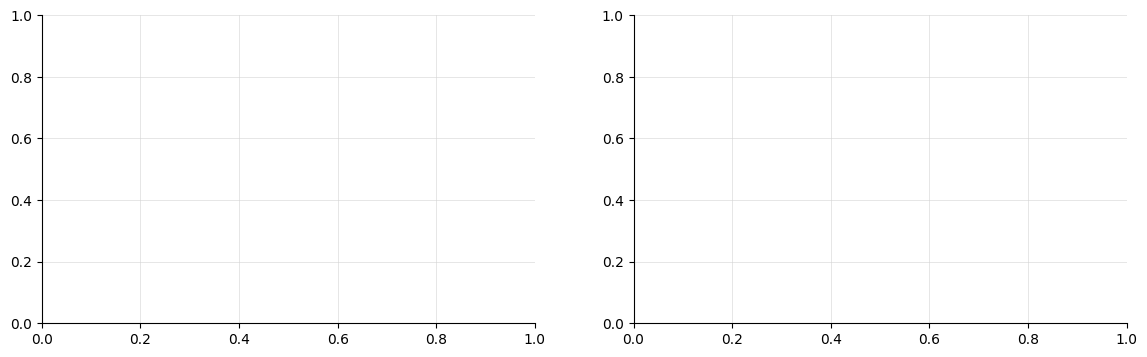

In [ ]:
vals_target = df['mwh_total'].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(vals_target, bins=80, color=VERDE, edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de mwh_total', fontweight='bold')
axes[0].set_xlabel('MWh')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(vals_target, vert=False, patch_artist=True,
                boxprops=dict(facecolor=VERDE, alpha=0.7),
                medianprops=dict(color='navy', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3, color=NARANJ))
axes[1].set_title('Boxplot de mwh_total', fontweight='bold')
axes[1].set_xlabel('MWh')

plt.tight_layout()
plt.show()


In [ ]:
print(f"sum(is.na(mwh_total)): {df['mwh_total'].null_count()}")


> **Observaciones:** *(completar tras ver outputs)*  
> — Si la distribución tiene cola derecha pronunciada → sesgo positivo, mayoría de bloques con consumo moderado y picos altos  
> — Outliers en el boxplot corresponden potencialmente a eventos de demanda extrema (verano/invierno)


## <font color='#4E8F6E'>  **Variables Explicativas Numéricas** </font>


#### <font color='#D4B93A'><b>Revisión</b></font>


In [ ]:
VARS_NUM = ['mwh_industria', 'mwh_residencial', 'mwh_servicios', 'mwh_no_especificado',
            'lst_celsius', 'temp_mean', 'temp_max', 'temp_min',
            'humedad_mean', 'viento_mean', 'precipitacion_sum', 'irradiancia_mean']

df_num = df.select(VARS_NUM)
df_num.head(6)


In [ ]:
df.select(VARS_NUM + ['mwh_total']).null_count()

#### <font color='#D4B93A'><b>Resumen Descriptivo de variables numéricas</b></font>


In [ ]:
df.select(VARS_NUM).describe()

In [ ]:
# Top 10 registros por consumo — revisar si las variables coinciden en extremos
df.sort('mwh_total', descending=True).select(
    ['datetime', 'cod_postal', 'mwh_total', 'temp_mean', 'lst_celsius', 'hora', 'mes']
).head(10)


> *(Anotar coincidencias entre picos de consumo y temperatura extrema, hora punta, mes de verano/invierno)*


In [ ]:
# Histogramas + boxplots para todas las variables numéricas
n_cols = 3
n_rows = int(np.ceil(len(VARS_NUM) / n_cols))

fig = plt.figure(figsize=(16, n_rows * 5))

for i, var in enumerate(VARS_NUM):
    v = df[var].drop_nulls().to_numpy()
    
    # Histograma
    ax1 = fig.add_subplot(n_rows * 2, n_cols, (i // n_cols) * n_cols * 2 + (i % n_cols) + 1)
    ax1.hist(v, bins=30, color=VERDE, edgecolor='white', alpha=0.85)
    ax1.set_title(var, fontsize=9)
    ax1.set_ylabel('Frecuencia', fontsize=7)
    
    # Boxplot
    ax2 = fig.add_subplot(n_rows * 2, n_cols, (i // n_cols) * n_cols * 2 + n_cols + (i % n_cols) + 1)
    ax2.boxplot(v, vert=False, patch_artist=True,
                boxprops=dict(facecolor=VERDE, alpha=0.7),
                medianprops=dict(color='#2d5a42', linewidth=1.5),
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    ax2.set_xlabel('', fontsize=7)

plt.suptitle('Distribución de variables numéricas', fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()


> *(Anotar aquí sesgos identificados por variable — e.g. precipitación muy concentrada en 0, irradiancia bimodal por día/noche, etc.)*


#### <font color='#D4B93A'><b>Normalidad</b></font>


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(VARS_NUM):
    v = df[var].drop_nulls().to_numpy()
    stats.probplot(v, dist='norm', plot=axes[i])
    axes[i].get_lines()[0].set(color=VERDE, alpha=0.4, markersize=2)
    axes[i].get_lines()[1].set(color=NARANJ, linewidth=2)
    axes[i].set_title(var, fontsize=9)
    axes[i].grid(color='grey85', linewidth=0.4)

plt.suptitle('QQ-plots — variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> Los QQ-plots confirman que ninguna variable sigue una distribución normal.  
> Para **correlación** no se podrá usar Pearson (asume normalidad) → se usará **Spearman**.  
> Para tests de hipótesis numérica vs objetivo → **Mann-Whitney / Kruskal-Wallis**.


#### <font color='#D4B93A'><b>Análisis Bivariante Numérico</b></font>


In [ ]:
# Dividir mwh_total en bajo (Q1) vs alto (Q3) para comparar distribuciones
q1_t = df['mwh_total'].quantile(0.25)
q3_t = df['mwh_total'].quantile(0.75)
df_bajo = df.filter(pl.col('mwh_total') <= q1_t)
df_alto = df.filter(pl.col('mwh_total') >= q3_t)

VARS_BIV = ['temp_mean', 'humedad_mean', 'viento_mean', 'irradiancia_mean', 'lst_celsius',
            'precipitacion_sum']

n_cols_b = 3
n_rows_b = int(np.ceil(len(VARS_BIV) / n_cols_b))

fig, axes = plt.subplots(n_rows_b * 2, n_cols_b, figsize=(16, n_rows_b * 5))

for i, var in enumerate(VARS_BIV):
    row_h = (i // n_cols_b) * 2
    row_b = row_h + 1
    col   = i % n_cols_b
    
    v_bajo = df_bajo[var].drop_nulls().to_numpy()
    v_alto = df_alto[var].drop_nulls().to_numpy()
    
    # Histogramas superpuestos
    axes[row_h, col].hist(v_bajo, bins=30, alpha=0.6, color=AZUL,   label='mwh bajo (Q1)', density=True)
    axes[row_h, col].hist(v_alto, bins=30, alpha=0.6, color=NARANJ, label='mwh alto (Q3)', density=True)
    axes[row_h, col].set_title(var, fontsize=9)
    axes[row_h, col].set_ylabel('Densidad', fontsize=7)
    axes[row_h, col].legend(fontsize=7)
    
    # Boxplots comparativos
    bp = axes[row_b, col].boxplot([v_bajo, v_alto], vert=False, patch_artist=True,
                                   labels=['mwh bajo', 'mwh alto'],
                                   medianprops=dict(color='navy', linewidth=1.5))
    bp['boxes'][0].set_facecolor(AZUL);  bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(NARANJ); bp['boxes'][1].set_alpha(0.7)

plt.suptitle('Bivariante: variables meteo según nivel de consumo (Q1 vs Q3)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


> Las variables que mejor separan consumo bajo vs alto son: *(completar)*.  
> Variables donde la distribución apenas difiere: *(completar)*.


## <font color='#4E8F6E'>  **Variables Explicativas Categóricas / Temporales** </font>


#### <font color='#D4B93A'><b>Revisión</b></font>


In [ ]:
VARS_CAT = ['hora', 'dia_semana', 'mes', 'es_finde', 'es_festivo', 'cod_postal']

print("=== VALORES ÚNICOS ===")
for v in VARS_CAT:
    print(f"  {v:<20} {df[v].n_unique():>5} valores únicos")


#### <font color='#D4B93A'><b>Variables Categóricas Binarias</b></font>


In [ ]:
# Distribución de es_finde y es_festivo (análogo a barplot de distribución)
VARS_BIN = ['es_finde', 'es_festivo']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, var in zip(axes, VARS_BIN):
    counts = df[var].value_counts().sort(var)
    vals_b = counts[var].to_list()
    cnts   = counts['count'].to_list()
    pcts   = [c / sum(cnts) * 100 for c in cnts]
    
    bars = ax.bar([str(v) for v in vals_b], pcts,
                  color=[VERDE, NARANJ], edgecolor='white')
    ax.set_title(f'Distribución de {var}', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Porcentaje (%)')
    
    for bar, p in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{p:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


> *(Anotar si hay desbalance — e.g. festivos son minoría, fines de semana aprox 2/7)*


#### <font color='#D4B93A'><b>Variables Categóricas NO Binarias</b></font>


In [ ]:
# Consumo medio por hora del día
hora_agg = (
    df.group_by('hora')
    .agg(pl.col('mwh_total').mean().alias('mwh_medio'))
    .sort('hora')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([str(h) + 'h' for h in hora_agg['hora'].to_list()],
       hora_agg['mwh_medio'].to_list(),
       color=VERDE, edgecolor='white', alpha=0.85)
ax.set_title('Consumo medio por hora del día', fontweight='bold')
ax.set_xlabel('Hora')
ax.set_ylabel('MWh medio')
plt.tight_layout()
plt.show()


In [ ]:
# Consumo medio por día de la semana
DIAS = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

dia_agg = (
    df.group_by('dia_semana')
    .agg(pl.col('mwh_total').mean().alias('mwh_medio'))
    .sort('dia_semana')
)

colores_dia = [VERDE if d < 5 else NARANJ for d in dia_agg['dia_semana'].to_list()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(DIAS, dia_agg['mwh_medio'].to_list(),
       color=colores_dia, edgecolor='white', alpha=0.85)
ax.set_title('Consumo medio por día de la semana', fontweight='bold')
ax.set_xlabel('Día')
ax.set_ylabel('MWh medio')
plt.tight_layout()
plt.show()


In [ ]:
# Consumo medio por mes (estacionalidad anual)
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

mes_agg = (
    df.group_by('mes')
    .agg(pl.col('mwh_total').mean().alias('mwh_medio'))
    .sort('mes')
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(MESES, mes_agg['mwh_medio'].to_list(),
       color=AZUL, edgecolor='white', alpha=0.85)
ax.set_title('Consumo medio por mes (estacionalidad anual)', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('MWh medio')
plt.tight_layout()
plt.show()


In [ ]:
# Tasa de consumo alto (>=P75) por código postal
umbral_p75 = df['mwh_total'].quantile(0.75)

tasa_cp = (
    df.with_columns((pl.col('mwh_total') >= umbral_p75).cast(pl.Int8).alias('es_alto'))
    .group_by('cod_postal')
    .agg(
        (pl.col('es_alto').mean() * 100).round(1).alias('pct_alto'),
        pl.col('mwh_total').mean().round(2).alias('mwh_medio'),
        pl.len().alias('n')
    )
    .sort('pct_alto', descending=True)
)

print("=== TOP 15 códigos postales por % consumo alto ===")
print(tasa_cp.head(15))


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(tasa_cp['cod_postal'].to_list(),
       tasa_cp['pct_alto'].to_list(),
       color=VERDE, edgecolor='white', alpha=0.85)
ax.axhline(25, color='red', linestyle='--', linewidth=1.5, label='Referencia 25%')
ax.set_title('% de bloques con consumo alto (≥P75) por código postal', fontweight='bold')
ax.set_xlabel('Código postal')
ax.set_ylabel('% consumo alto')
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.legend()
plt.tight_layout()
plt.show()


## <font color='#4E8F6E'> **Conclusiones del EDA** </font>

*(Completar tras ejecutar todo)*

El dataset presenta X registros a granularidad de 6h por código postal. La variable objetivo `mwh_total` 
muestra sesgo positivo con cola derecha pronunciada, indicando que la mayoría de bloques tienen consumo 
moderado pero existen picos elevados. Ninguna variable numérica sigue distribución normal (confirmado por 
QQ-plots), por lo que se usará **Spearman** para correlaciones y **Kruskal-Wallis / Mann-Whitney** para tests de hipótesis.

> *(Anotar las variables que mejor separan consumo bajo/alto, patrones temporales destacados, y los principales retos: gaps Meteocat, outliers extremos, estacionalidad múltiple)*

#### <font color='#D4B93A'> **Estas conclusiones deben tomarse con cautela hasta completar el análisis completo con todos los datos disponibles.** </font>


---
# <font color='#4E8F6E'>  **Selección de variables** </font>


## <font color='#4E8F6E'>  **Test de Hipótesis** </font>


#### <font color='#D4B93A'><b>Kruskal-Wallis — Variables Temporales</b></font>


> **Recordatorio:** Los tests de hipótesis responden ¿lo que observo en los datos es real o podría ser producto del azar?

- **Evidencia estadística vs H0**
- Variable objetivo es continua (`mwh_total`) → no se puede usar Chi² directamente
- Se usa **Kruskal-Wallis** para categóricas con múltiples niveles (hora, mes, dia_semana) — alternativa no paramétrica al ANOVA
- Se usa **Mann-Whitney** para binarias (es_finde, es_festivo)

**Objetivo:** Detectar asociaciones significativas entre las variables explicativas y `mwh_total`. Filtrar variables potencialmente relevantes para el modelo.

- **H0:** La distribución de `mwh_total` es igual en todos los grupos de la variable categórica
- **H1:** Existe diferencia significativa en `mwh_total` entre grupos


In [ ]:
VARS_TEMP = ['hora', 'dia_semana', 'mes']

resultados_kw = []
for var in VARS_TEMP:
    grupos = [
        df.filter(pl.col(var) == v)['mwh_total'].drop_nulls().to_numpy()
        for v in df[var].unique().sort().to_list()
    ]
    h_stat, p_val = stats.kruskal(*grupos)
    resultados_kw.append({
        'variable':      var,
        'H_stat':        round(h_stat, 3),
        'p_value':       p_val,
        'significativo': 'significativo' if p_val < 0.05 else 'no significativo'
    })

print(f"{'variable':<20} {'H_stat':>12} {'p_value':>14} {'significativo':>16}")
print('-' * 70)
for r in resultados_kw:
    print(f"{r['variable']:<20} {r['H_stat']:>12.3f} {r['p_value']:>14.4e} {r['significativo']:>16}")


> *(Anotar si hora, mes y dia_semana son estadísticamente significativas — esperamos que sí, dada la estacionalidad del consumo)*


#### <font color='#D4B93A'><b>Mann-Whitney — Variables Binarias</b></font>


> **Objetivo:** Detectar si `mwh_total` difiere significativamente entre 0 y 1 en variables binarias.  
> - **H0:** La distribución de `mwh_total` es igual entre grupos  
> - **H1:** Existe diferencia significativa


In [ ]:
VARS_BIN_TEST = ['es_finde', 'es_festivo']

print(f"{'variable':<20} {'mediana_0':>12} {'mediana_1':>12} {'p_value':>14} {'significativo':>16}")
print('-' * 80)

for var in VARS_BIN_TEST:
    g0 = df.filter(pl.col(var) == 0)['mwh_total'].drop_nulls().to_numpy()
    g1 = df.filter(pl.col(var) == 1)['mwh_total'].drop_nulls().to_numpy()
    stat_mw, p_mw = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = 'significativo' if p_mw < 0.05 else 'no significativo'
    print(f"{var:<20} {np.median(g0):>12.2f} {np.median(g1):>12.2f} {p_mw:>14.4e} {sig:>16}")


In [ ]:
# Visualización: distribución de mwh_total según es_finde y es_festivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var, titulo in zip(axes,
                            ['es_finde', 'es_festivo'],
                            ['Fin de semana', 'Festivo']):
    g0 = df.filter(pl.col(var) == 0)['mwh_total'].drop_nulls().to_numpy()
    g1 = df.filter(pl.col(var) == 1)['mwh_total'].drop_nulls().to_numpy()
    
    ax.hist(g0, bins=40, alpha=0.6, color=VERDE,  label='No (0)', density=True)
    ax.hist(g1, bins=40, alpha=0.6, color=NARANJ, label='Sí (1)', density=True)
    ax.set_title(f'mwh_total según {titulo}', fontweight='bold')
    ax.set_xlabel('MWh')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()


#### <font color='#D4B93A'><b>Mann-Whitney — Variables Numéricas vs mwh_total</b></font>


> **Objetivo:** Detectar diferencias significativas en la distribución de las variables numéricas entre bloques de consumo bajo (Q1) y alto (Q3).  
> - **H0:** La distribución de la variable numérica es igual en consumo bajo y alto  
> - **H1:** Existe diferencia significativa


In [ ]:
# Comparar distribución de cada var numérica entre mwh bajo (Q1) y mwh alto (Q3)
q1_t = df['mwh_total'].quantile(0.25)
q3_t = df['mwh_total'].quantile(0.75)

resultados_mw = []
for var in VARS_NUM:
    df_pair = df.select([var, 'mwh_total']).drop_nulls()
    g_bajo = df_pair.filter(pl.col('mwh_total') <= q1_t)[var].to_numpy()
    g_alto = df_pair.filter(pl.col('mwh_total') >= q3_t)[var].to_numpy()
    stat_mw, p_mw = stats.mannwhitneyu(g_bajo, g_alto, alternative='two-sided')
    resultados_mw.append({
        'variable':      var,
        'mediana_bajo':  round(float(np.median(g_bajo)), 3),
        'mediana_alto':  round(float(np.median(g_alto)), 3),
        'p_value':       p_mw,
        'significativo': 'significativo' if p_mw < 0.05 else 'no significativo'
    })

res_mw = sorted(resultados_mw, key=lambda x: x['p_value'])

print(f"{'variable':<30} {'mediana_bajo':>14} {'mediana_alto':>14} {'p_value':>14} {'significativo':>16}")
print('-' * 95)
for r in res_mw:
    print(f"{r['variable']:<30} {r['mediana_bajo']:>14.3f} {r['mediana_alto']:>14.3f} {r['p_value']:>14.4e} {r['significativo']:>16}")


> *(Anotar qué variables muestran diferencias más marcadas entre consumo bajo y alto — estas serán las más relevantes para el modelo)*


---
## <font color='#4E8F6E'>  **Correlación** </font>


> Debido a la ausencia de normalidad confirmada en los QQ-plots, se usará **correlación de Spearman** en lugar de Pearson.


#### <font color='#D4B93A'><b>Tabla y gráfico</b></font>


In [ ]:
COLS_CORR = ['mwh_total', 'mwh_industria', 'mwh_residencial', 'mwh_servicios',
             'mwh_no_especificado', 'temp_mean', 'temp_max', 'temp_min',
             'humedad_mean', 'viento_mean', 'precipitacion_sum', 'irradiancia_mean', 'lst_celsius']

df_corr_np = df.select(COLS_CORR).drop_nulls().to_numpy()
matrizcor, _ = stats.spearmanr(df_corr_np)

import pandas as pd
matrizcor_df = pd.DataFrame(np.round(matrizcor, 2), columns=COLS_CORR, index=COLS_CORR)
print(matrizcor_df)


In [ ]:
fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(matrizcor, dtype=bool))
sns.heatmap(
    matrizcor,
    annot=True, fmt='.2f',
    cmap=sns.diverging_palette(10, 133, as_cmap=True),
    xticklabels=COLS_CORR, yticklabels=COLS_CORR,
    center=0, vmin=-1, vmax=1,
    mask=mask, ax=ax,
    linewidths=0.5, annot_kws={'size': 7},
    cbar_kws={'label': 'Spearman'}
)
ax.set_title('Matriz de Correlación (Spearman)', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


> *(Anotar grupos de alta correlación — e.g. temp_mean/temp_max/temp_min están correlacionadas entre sí.  
> Variables 7 days equivalentes en el TFM serían los sectores de consumo — pueden tener alta correlación con mwh_total.  
> LST vs temp_mean: correlación esperada pero no perfecta — justifica mantener ambas por capturar señales distintas)*


In [ ]:
# Correlación de Spearman de cada variable con mwh_total
resultados_spearman = []
for var in VARS_NUM:
    df_pair = df.select([var, 'mwh_total']).drop_nulls()
    corr, p_val = stats.spearmanr(df_pair[var].to_numpy(), df_pair['mwh_total'].to_numpy())
    resultados_spearman.append({
        'variable':      var,
        'spearman_r':    round(corr, 4),
        'p_value':       round(p_val, 6),
        'significativo': 'significativo' if p_val < 0.05 else 'no significativo'
    })

res_sp = sorted(resultados_spearman, key=lambda x: abs(x['spearman_r']), reverse=True)

print(f"{'variable':<30} {'spearman_r':>12} {'p_value':>12} {'significativo':>16}")
print('-' * 80)
for r in res_sp:
    print(f"{r['variable']:<30} {r['spearman_r']:>12.4f} {r['p_value']:>12.6f} {r['significativo']:>16}")


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
variables  = [r['variable'] for r in res_sp]
correlaciones = [r['spearman_r'] for r in res_sp]
colores_bar = [VERDE if c >= 0 else NARANJ for c in correlaciones]

ax.barh(variables, correlaciones, color=colores_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Spearman con mwh_total', fontweight='bold')
ax.set_xlabel('Spearman r')
plt.tight_layout()
plt.show()


---
## <font color='#4E8F6E'>  **PCA** </font>


In [ ]:
# Preparar matriz sin nulos
df_pca_raw = df.select(VARS_NUM).drop_nulls().to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_raw)

pca = PCA(n_components=len(VARS_NUM))
pca.fit(X_scaled)

# Resumen de varianza explicada
var_exp_ratio = pca.explained_variance_ratio_
var_acum      = np.cumsum(var_exp_ratio)

print(f"{'PC':<6} {'Var explicada':>15} {'Var acumulada':>15}")
print('-' * 40)
for i, (v, va) in enumerate(zip(var_exp_ratio, var_acum)):
    print(f"PC{i+1:<4} {v:>14.4f} {va:>14.4f}")


#### <font color='#D4B93A'><b>Codo</b></font>


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(var_acum) + 1), var_acum,
        'o-', color='steelblue', linewidth=2, markersize=6)

ax.axhline(0.90, color='red', linewidth=2, linestyle='--')
ax.text(len(var_acum) * 0.6, 0.92, '90%', color='red', fontsize=10)

ax.set_title('Gráfico de Codo — Varianza Acumulada', fontweight='bold')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza Explicada Acumulada')
ax.set_ylim(0, 1)
ax.grid(color='grey85', linewidth=0.4)
plt.tight_layout()
plt.show()


> La línea al nivel 90% indica cuántos componentes son necesarios. *(Completar tras ver el gráfico)*


#### <font color='#D4B93A'><b>Loadings</b></font>


In [ ]:
# Scores (primeras filas)
scores = pca.transform(X_scaled)
scores_df = pd.DataFrame(scores, columns=[f'PC{i+1}' for i in range(len(VARS_NUM))])
print("Scores (primeras filas):")
print(scores_df.head())


In [ ]:
# Loadings — contribución de cada variable a cada PC
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=VARS_NUM,
    columns=[f'PC{i+1}' for i in range(len(VARS_NUM))]
).round(4)

print("Loadings:")
print(loadings_df)


In [ ]:
# Heatmap de loadings — PC1 a PC5
n_pcs_show = min(5, len(VARS_NUM))

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    loadings_df.iloc[:, :n_pcs_show],
    annot=True, fmt='.2f',
    cmap=sns.diverging_palette(10, 133, as_cmap=True),
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 9},
    ax=ax, cbar_kws={'label': 'Loading'}
)
ax.set_title('Loadings PCA — PC1 a PC5', fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()


> **PC1** — *(Anotar qué variables tienen mayor carga: esperamos temperatura/LST o sectores de consumo)*  
> **PC2** — *(Anotar dimensión independiente que captura, e.g. precipitación o irradiancia)*  
> Variables con alta carga en los primeros PCs son señales fuertes para el modelo.


In [ ]:
# Biplot simplificado — PC1 vs PC2 coloreado por mes
fig, ax = plt.subplots(figsize=(10, 7))

# Sample para no saturar el plot
idx = np.random.choice(len(scores), size=min(3000, len(scores)), replace=False)
sc = ax.scatter(scores[idx, 0], scores[idx, 1],
                c=df.select('mes').drop_nulls().to_numpy().flatten()[idx],
                cmap='tab12', alpha=0.4, s=8)

# Vectores de loadings
scale = np.abs(scores).max() * 0.4
for i, var in enumerate(VARS_NUM):
    ax.arrow(0, 0,
             pca.components_[0, i] * scale,
             pca.components_[1, i] * scale,
             head_width=0.15, head_length=0.1, color=NARANJ, alpha=0.8)
    ax.text(pca.components_[0, i] * scale * 1.15,
            pca.components_[1, i] * scale * 1.15,
            var, fontsize=7, color=NARANJ, ha='center')

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp_ratio[0]*100:.1f}% var explicada)')
ax.set_ylabel(f'PC2 ({var_exp_ratio[1]*100:.1f}% var explicada)')
ax.set_title('Biplot PCA — PC1 vs PC2 (coloreado por mes)', fontweight='bold')
plt.colorbar(sc, ax=ax, label='Mes')
plt.tight_layout()
plt.show()


---
## <font color='#4E8F6E'>  **Selección de variables para el modelo** </font>


#### <font color='#D4B93A'><b>Tests de Hipótesis + Correlación + PCA</b></font>


> **Variables seleccionadas para el modelo:** *(Completar tras analizar los outputs)*

**Variables numéricas meteorológicas:**
- `temp_mean` — correlación directa con consumo (calor/frío → climatización)
- `lst_celsius` — captura variación espacial intraurbana (Salvati et al. 2017: hasta 4.3°C entre barrios)
- `irradiancia_mean` — señal de hora y estación, proxy de temperatura solar
- `humedad_mean` — efecto sobre percepción de temperatura
- *(descartar variables con alta colinealidad: temp_max/temp_min si temp_mean ya está incluida)*

**Variables de calendario:**
- `hora` — patrón diario de consumo (K-W significativo)
- `dia_semana` — laborable vs fin de semana (K-W significativo)
- `mes` — estacionalidad anual (K-W significativo)
- `es_finde` — Mann-Whitney significativo
- `es_festivo` — Mann-Whitney significativo

**Lags y rolling (feature engineering — siguiente fase):**
- `lag_1`, `lag_4`, `lag_28` — autocorrelación temporal
- `rolling_mean_7d` — tendencia de corto plazo

**Se descartan:** *(completar — e.g. variables con alta colinealidad entre sí que no aportan dimensiones independientes según PCA)*



In [ ]:
# Resumen ejecutivo
q1_v = df['mwh_total'].quantile(0.25)
q3_v = df['mwh_total'].quantile(0.75)
iqr_v = q3_v - q1_v
n_outliers = df.filter(
    (pl.col('mwh_total') < q1_v - 1.5 * iqr_v) |
    (pl.col('mwh_total') > q3_v + 1.5 * iqr_v)
).shape[0]

print('=' * 60)
print('  RESUMEN EDA — Predicción Energética BCN')
print('=' * 60)
print(f'  Registros totales:    {len(df):>12,}')
print(f'  Códigos postales:     {df["cod_postal"].n_unique():>12}')
print(f'  Período:              {df["datetime"].min()} → {df["datetime"].max()}')
print(f'  mwh_total media:      {df["mwh_total"].mean():>12.2f} MWh')
print(f'  mwh_total mediana:    {df["mwh_total"].median():>12.2f} MWh')
print(f'  mwh_total std:        {df["mwh_total"].std():>12.2f} MWh')
print(f'  mwh_total máximo:     {df["mwh_total"].max():>12.2f} MWh')
print(f'  Outliers IQR:         {n_outliers:>12,} ({n_outliers/len(df)*100:.2f}%)')
print()
print('  Próximos pasos:')
print('  [ ] Imputación nulos Meteocat (X2 inactiva 2025)')
print('  [ ] Feature engineering: lags, rolling, variables de calendario')
print('  [ ] ADF / KPSS: test formal de estacionariedad')
print('  [ ] ACF / PACF: identificar órdenes para SARIMA')
print('  [ ] Correlación cruzada consumo-temperatura con desfase temporal')
